<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [28]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [49]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [50]:
# Creating a pandas dataframe including the stats values
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Missing Count": df.count(),
    "Missing Values": df.isnull().sum()
})

summary

,Data Type,Non-Missing Count,Missing Values
ResponseId,int64,65437,0
MainBranch,str,65437,0
Age,str,65437,0
Employment,str,65437,0
RemoteWork,str,54806,10631
...,...,...,...
JobSatPoints_11,float64,29445,35992
SurveyLength,str,56182,9255
SurveyEase,str,56238,9199
ConvertedCompYearly,float64,23435,42002


<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [51]:
# Generate basic statistics for numerical columns
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [52]:
# Checking unique Countries
countries = df["Country"].unique()
countries

<ArrowStringArray>
[                            'United States of America',
 'United Kingdom of Great Britain and Northern Ireland',
                                               'Canada',
                                               'Norway',
                                           'Uzbekistan',
                                               'Serbia',
                                               'Poland',
                                          'Philippines',
                                             'Bulgaria',
                                          'Switzerland',
 ...
                                'Saint Kitts and Nevis',
                                               'Monaco',
                   'Micronesia, Federated States of...',
                                                'Haiti',
                                                    nan,
                                                'Nauru',
                                              'Liberia',
       

In [53]:
# Look for suspicious or inconsistent entries
for country in countries:
    print(country)

United States of America
United Kingdom of Great Britain and Northern Ireland
Canada
Norway
Uzbekistan
Serbia
Poland
Philippines
Bulgaria
Switzerland
India
Germany
Ireland
Italy
Ukraine
Australia
Brazil
Japan
Austria
Iran, Islamic Republic of...
France
Saudi Arabia
Romania
Turkey
Nepal
Algeria
Sweden
Netherlands
Croatia
Pakistan
Czech Republic
Republic of North Macedonia
Finland
Slovakia
Russian Federation
Greece
Israel
Belgium
Mexico
United Republic of Tanzania
Hungary
Argentina
Portugal
Sri Lanka
Latvia
China
Singapore
Lebanon
Spain
South Africa
Lithuania
Viet Nam
Dominican Republic
Indonesia
Kosovo
Morocco
Taiwan
Georgia
San Marino
Tunisia
Bangladesh
Nigeria
Liechtenstein
Denmark
Ecuador
Malaysia
Albania
Azerbaijan
Chile
Ghana
Peru
Bolivia
Egypt
Luxembourg
Montenegro
Cyprus
Paraguay
Kazakhstan
Slovenia
Jordan
Venezuela, Bolivarian Republic of...
Costa Rica
Jamaica
Thailand
Nicaragua
Myanmar
Republic of Korea
Rwanda
Bosnia and Herzegovina
Benin
El Salvador
Zimbabwe
Afghanistan
Estoni

<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [54]:
# Creating a mapping to standardize countries names
country_mapping = {
    "United States of America": "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Iran, Islamic Republic of...": "Iran",
    "Viet Nam": "Vietnam",
    "Czech Republic": "Czechia",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Russian Federation": "Russia",
    "Swaziland": "Eswatini",
    "United Republic of Tanzania": "Tanzania",
    "Lao People's Democratic Republic": "Laos",
    "Syrian Arab Republic": "Syria",
    "Libyan Arab Jamahiriya": "Libya",
    "Congo, Republic of the...": "Republic of the Congo",
    "Micronesia, Federated States of...": "Micronesia",
}

# Keeping original number of Countries for checking afterwards
original_country_count = df["Country"].nunique()

# Standardizing countries names
df["Country"] = df["Country"].replace(country_mapping)
df["Country"].value_counts().head(20)

Country
United States     11095
Germany            4947
India              4231
United Kingdom     3224
Ukraine            2672
France             2110
Canada             2104
Poland             1534
Netherlands        1449
Brazil             1375
Italy              1341
Australia          1260
Spain              1123
Sweden             1016
Russia              925
Switzerland         876
Austria             791
Czechia             714
Israel              604
Turkey              546
Name: count, dtype: int64

In [55]:
new_country_count = df["Country"].nunique()

print("Before Countries normalization:", original_country_count)
print("After Countries normalization:", new_country_count)

Before Countries normalization: 185
After Countries normalization: 183

### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [56]:
# The goal is to convert the categorical Employment column into separate binary (0/1) columns
# get_dummies function on pandas creates the one-hot encoded columns based on the columns values
employment_encoded = pd.get_dummies(
    df["Employment"],
    prefix="Employment",
    dtype=int
)

employment_encoded.head()

# Adding the enconding columns to the dataset
df = pd.concat(
    [df, employment_encoded],
    axis=1
)

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,"Employment_Student, full-time;Not employed, but looking for work;Not employed, and not looking for work;Student, part-time","Employment_Student, full-time;Not employed, but looking for work;Retired","Employment_Student, full-time;Not employed, but looking for work;Student, part-time","Employment_Student, full-time;Retired","Employment_Student, full-time;Student, part-time","Employment_Student, full-time;Student, part-time;Employed, part-time","Employment_Student, full-time;Student, part-time;Retired","Employment_Student, part-time","Employment_Student, part-time;Employed, part-time","Employment_Student, part-time;Retired"
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,0,0,0,0,0,0,0,0,0,0
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0,0,0,0,0,0,0,0,0,0
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0,0,0,0,0,0,0,0,0,0
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,0,0,0,0,0,0,0,0,0,0
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# Filtering just Employment related columns
print(df.filter(like="Employment_").columns)

Index(['Employment_Employed, full-time',
       'Employment_Employed, full-time;Employed, part-time',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Retired',
       'Employment_Employed,

### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [57]:
# Missing values numbers
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)
missing_values

AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
YearsCode                      5568
NEWSOSites                     5151
LearnCode                      4949
EdLevel                        4653
AISelect                       4530
Length: 109, dtype: int64

In [58]:
# Missing values percentages
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    "Missing Values",
    ascending=False
)

missing_summary

,Missing Values,Missing Percentage
AINextMuch less integrated,64289,98.25
AINextLess integrated,63082,96.40
AINextNo change,52939,80.90
AINextMuch more integrated,51999,79.46
EmbeddedAdmired,48704,74.43
...,...,...
YearsCode,5568,8.51
NEWSOSites,5151,7.87
LearnCode,4949,7.56
EdLevel,4653,7.11


<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [59]:
# Checking missing values in `ConvertedCompYearly`
print(df["ConvertedCompYearly"].isnull().sum())

# Calculating the median
median_comp = df["ConvertedCompYearly"].median()
print(f"Median compensation: {median_comp}")

# Inputing missing values
df["ConvertedCompYearly"] = df["ConvertedCompYearly"].fillna(median_comp)

# Verifying inputation
print(
    "Missing values after imputation:",
    df["ConvertedCompYearly"].isnull().sum()
)

42002
Median compensation: 65000.0
Missing values after imputation: 0

<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [60]:
# Checking missing values count before inputation
missing_before = df["RemoteWork"].isnull().sum()

# Checking the distribution
print(df["RemoteWork"].value_counts(dropna=False))

# Finding the most frequent value
most_frequent = df["RemoteWork"].mode()[0]
print("Most frequent RemoteWork value:", most_frequent)

# Inputing missing values
df["RemoteWork"] = df["RemoteWork"].fillna(most_frequent)

# Verify
missing_after = df["RemoteWork"].isnull().sum()

print(f"Missing values before: {missing_before}")
print(f"Most frequent value: {most_frequent}")
print(f"Missing values after: {missing_after}")

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
NaN                                     10631
Name: count, dtype: int64
Most frequent RemoteWork value: Hybrid (some remote, some in-person)
Missing values before: 10631
Most frequent value: Hybrid (some remote, some in-person)
Missing values after: 0

### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


In [61]:
# The Min-Max formula is: xnormalized = (x - xmin / xmax - xmin)
min_comp = df["ConvertedCompYearly"].min()
max_comp = df["ConvertedCompYearly"].max()

# Min-Max scaling
df["ConvertedCompYearly_MinMax"] = (
    (df["ConvertedCompYearly"] - min_comp)
    / (max_comp - min_comp)
)

# Verifying the result
df[["ConvertedCompYearly", "ConvertedCompYearly_MinMax"]].head()

,ConvertedCompYearly,ConvertedCompYearly_MinMax
0,65000.0,0.003998
1,65000.0,0.003998
2,65000.0,0.003998
3,65000.0,0.003998
4,65000.0,0.003998


In [62]:
# Verifying the ConvertedCompYearly_MinMax range
print("Minimum:", df["ConvertedCompYearly_MinMax"].min())
print("Maximum:", df["ConvertedCompYearly_MinMax"].max())

Minimum: 0.0
Maximum: 1.0

<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


In [64]:
# The goal is to apply a log transformation to ConvertedCompYearly to reduce the effect of extreme high compensation values and make the distribution less right-skewed
# Because compensation can contain zero or potentially negative values, I recommend using np.log1p() rather than np.log().
# Applying the log transformation
df["ConvertedCompYearly_Log"] = np.log1p(df["ConvertedCompYearly"])

# Verifying log transformation
df[
    ["ConvertedCompYearly", "ConvertedCompYearly_Log"]
].head()

,ConvertedCompYearly,ConvertedCompYearly_Log
0,65000.0,11.082158
1,65000.0,11.082158
2,65000.0,11.082158
3,65000.0,11.082158
4,65000.0,11.082158


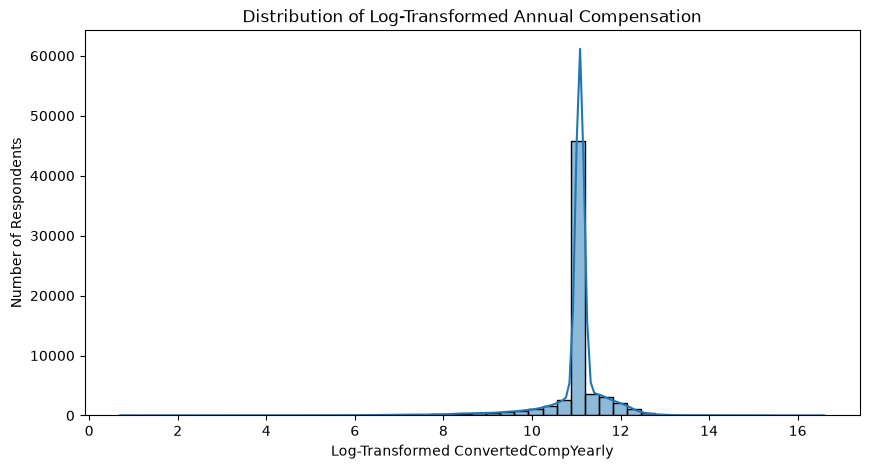

In [66]:
# Generating a histogram with ConvertedCompYearly_Log to check skewness
plt.figure(figsize=(10, 5))

sns.histplot(
    df["ConvertedCompYearly_Log"],
    bins=50,
    kde=True
)

plt.title("Distribution of Log-Transformed Annual Compensation")
plt.xlabel("Log-Transformed ConvertedCompYearly")
plt.ylabel("Number of Respondents")

plt.show()

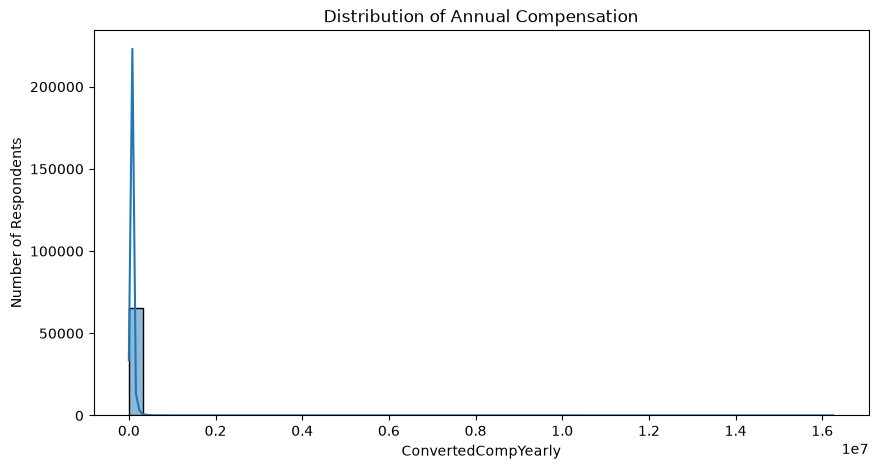

In [67]:
# Generating a histogram with ConvertedCompYearly to check skewness
plt.figure(figsize=(10, 5))

sns.histplot(
    df["ConvertedCompYearly"],
    bins=50,
    kde=True
)

plt.title("Distribution of Annual Compensation")
plt.xlabel("ConvertedCompYearly")
plt.ylabel("Number of Respondents")

plt.show()

### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


In [71]:
# For this task, you need to create a categorical ExperienceLevel column from the numeric/ordinal YearsCodePro values.
# Inspecting YearsCodePro
df["YearsCodePro"].value_counts(dropna=False)

# Converting YearsCodePro to numeric
df["YearsCodePro"] = df["YearsCodePro"].replace({
    "Less than 1 year": "0",
    "More than 50 years": "51"
})

df["YearsCodePro"] = pd.to_numeric(
    df["YearsCodePro"],
    errors="coerce"
)

# Create ExperienceLevel new feature
df["ExperienceLevel"] = pd.cut(
    df["YearsCodePro"],
    bins=[-1, 2, 7, 15, float("inf")],
    labels=[
        "Beginner",
        "Intermediate",
        "Advanced",
        "Expert"
    ]
)

# Verifying the columns
df[["YearsCodePro", "ExperienceLevel"]].head(20)

,YearsCodePro,ExperienceLevel
0,NaN,NaN
1,17.0,Expert
2,27.0,Expert
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,7.0,Intermediate
7,NaN,NaN
8,NaN,NaN
9,11.0,Advanced


In [72]:
# Verifying the distribution
df["ExperienceLevel"].value_counts(dropna=False)

ExperienceLevel
Intermediate    16194
Advanced        14226
NaN             13827
Expert          11527
Beginner         9663
Name: count, dtype: int64

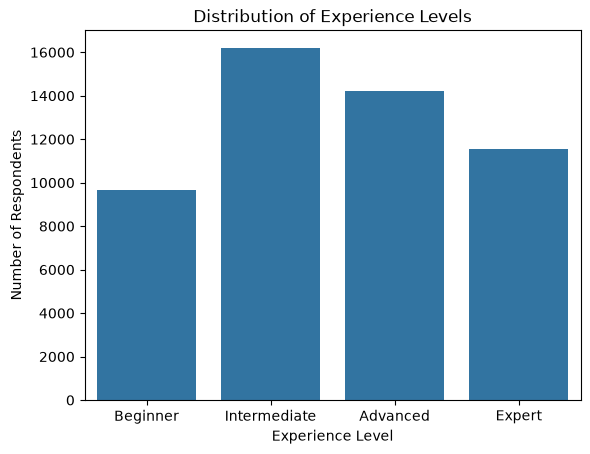

In [73]:
# Visualizing the distribution
sns.countplot(
    data=df,
    x="ExperienceLevel"
)

plt.title("Distribution of Experience Levels")
plt.xlabel("Experience Level")
plt.ylabel("Number of Respondents")

plt.show()

### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.


Copyright © IBM Corporation. All rights reserved.
